In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import load_digits  # Dữ liệu ví dụ
from sklearn.impute import SimpleImputer

In [10]:
# Đọc dữ liệu từ file CSV (thay 'data.csv' bằng đường dẫn file của bạn)
df = pd.read_csv("data/csv/cicddos_2019.csv")

In [11]:
selected_columns = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                    'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
                    'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
                    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
                    'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
                    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
                    'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
                    'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
                    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
                    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
                    'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']
df = df[selected_columns]

In [12]:
# Giả sử cột cuối cùng là nhãn, các cột còn lại là đặc trưng
X = df.drop(columns=['Label'])  # Tất cả các cột trừ cột cuối (features)
y = df['Label']   # Cột cuối cùng là nhãn (labels)


In [13]:
X.replace([-np.inf, np.inf], 0, inplace=True)
X.fillna(X.mean(), inplace=True)  # Điền giá trị NaN bằng giá trị trung vị

std = X.std()
std.replace(0, 1, inplace=True)

X = (X - X.mean()) / std
X = np.log1p(X + 1)

scaler = MinMaxScaler(feature_range=(0, 255))
X_scaled = scaler.fit_transform(X).astype(np.uint8)

# Tạo DataFrame mới nhưng giữ lại index và column names
X = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

f:\NCKH\code\DN\IDS-RESNET-50-System\train_model\.venv\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
C:\Users\NewTun\AppData\Local\Temp\ipykernel_9588\3977766833.py:11: RuntimeWarning: invalid value encountered in cast
  X_scaled = scaler.fit_transform(X).astype(np.uint8)


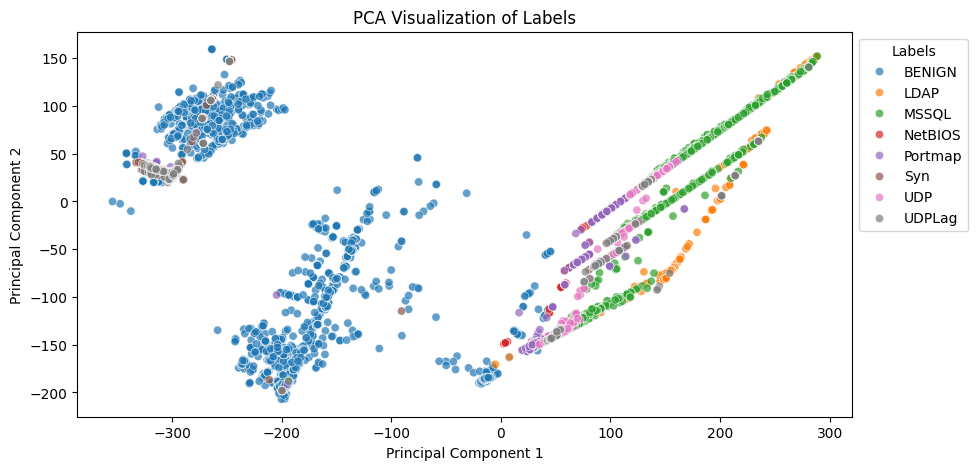

In [14]:
### 🔹 PCA để giảm xuống 2D ###
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10", alpha=0.7)
plt.title("PCA Visualization of Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Labels", bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
### 🔹 t-SNE để giảm xuống 2D ###
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="tab10", alpha=0.7)
plt.title("t-SNE Visualization of Labels")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Labels", bbox_to_anchor=(1, 1))
plt.show()